In [5]:
# ==========================
# 1. IMPORTS & CONFIG
# ==========================
import os
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import kornia

from skimage import color
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.color import deltaE_ciede2000

import timm
import lpips
from tqdm import tqdm

# Reproducibilidad básica
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

# Paths
DATA_ROOT = Path("data/imagewoof2-320")   # o imagenette, según uses
assert DATA_ROOT.exists(), "Dataset no encontrado"

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR   = DATA_ROOT / "val"

CHECKPOINT_DIR = Path("checkpoints")
RESULTS_DIR    = Path("results")
CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Hiperparámetros
IMAGE_SIZE        = 256
BATCH_SIZE        = 16
NUM_WORKERS       = 0
NUM_EPOCHS        = 50
FREEZE_VIT_EPOCHS = 10

# FASE B
LPIPS_WEIGHT = 0.1  # pequeño, para no romper el color exacto

print("Train path:", TRAIN_DIR)
print("Val path  :", VAL_DIR)


Usando dispositivo: cuda
Train path: data/imagewoof2-320/train
Val path  : data/imagewoof2-320/val


In [11]:
# ==========================
# 2. DATASET & DATALOADERS
# ==========================

class ImagenetLabDataset(Dataset):
    """
    Dataset que devuelve la imagen en espacio LAB:
    - Entrada: canal L normalizado a [0,1]
    - Target: canales a,b normalizados a [-1,1]
    """
    def __init__(self, root_dir, subset_fraction=1.0, size=256):
        self.size = size

        all_files = []
        for root, _, files in os.walk(root_dir):
            for f in files:
                if f.lower().endswith((".jpg", ".jpeg", ".png")):
                    all_files.append(os.path.join(root, f))

        total = int(len(all_files) * subset_fraction)
        self.files = all_files[:total]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]

        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            img = Image.new("RGB", (self.size, self.size))

        img = img.resize((self.size, self.size), Image.BICUBIC)

        lab = color.rgb2lab(np.array(img)).astype("float32")

        L  = lab[:, :, 0] / 100.0       # [0,100] → [0,1]
        ab = lab[:, :, 1:] / 128.0      # [-128,128] → [-1,1]

        L  = torch.from_numpy(L).unsqueeze(0)        # [1,H,W]
        ab = torch.from_numpy(ab).permute(2, 0, 1)   # [2,H,W]

        return L, ab


# Dataloaders
train_dataset = ImagenetLabDataset(root_dir=TRAIN_DIR, subset_fraction=0.35, size=IMAGE_SIZE)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS)

val_dataset_full = ImagenetLabDataset(root_dir=VAL_DIR, subset_fraction=1.0, size=IMAGE_SIZE)
val_loader_tmp   = DataLoader(val_dataset_full, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS)

# Cacheo validación en RAM
val_data_cached = []
for L_batch, ab_batch in tqdm(val_loader_tmp, desc="Cacheando validación"):
    val_data_cached.append((L_batch, ab_batch))

fixed_vis_batch = val_data_cached[0]
print("Validation cache completa. Ejemplos fijos listos.")


Cacheando validación:   0%|          | 0/246 [00:00<?, ?it/s]

Cacheando validación: 100%|██████████| 246/246 [00:43<00:00,  5.61it/s]

Validation cache completa. Ejemplos fijos listos.


In [6]:
# ==========================
# 3. ARQUITECTURA DEL MODELO
# ==========================

class SpatialSelfAttention(nn.Module):
    """
    Deja que el modelo "mire" toda la imagen a la vez,
    así no se queda trabado sólo con el pixel de al lado.
    """
    def __init__(self, in_channels):
        super().__init__()
        self.query_conv = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.key_conv   = nn.Conv2d(in_channels, in_channels // 8, 1)
        self.value_conv = nn.Conv2d(in_channels, in_channels, 1)
        self.gamma      = nn.Parameter(torch.zeros(1))
        self.softmax    = nn.Softmax(dim=-1)

    def forward(self, x):
        b, c, h, w = x.size()

        # Proyectamos a query/key/value (estilo transformer pero 2D)
        proj_query = self.query_conv(x).view(b, -1, h*w).permute(0, 2, 1)
        proj_key   = self.key_conv(x).view(b, -1, h*w)

        # Acá se calcula "qué pixel debería prestarle atención a cuál"
        energy     = torch.bmm(proj_query, proj_key)
        attention  = self.softmax(energy)

        # Mezcla la info global y la reinyecta
        proj_value = self.value_conv(x).view(b, -1, h*w)
        out        = torch.bmm(proj_value, attention.permute(0, 2, 1))
        out        = out.view(b, c, h, w)

        # Gamma controla cuánto aporta la atención vs el feature original
        return self.gamma * out + x



class HybridVitUnetColorizer(nn.Module):
    """
    Generador híbrido ViT + U-Net.
    
    - La parte CNN (U-Net) captura detalles y texturas.
    - El ViT captura la escena "completa" (entendimiento global).
    - Después fusionamos ambas cosas para que tenga coherencia de color
      y no pinte cada objeto como se le antoja.
    """
    def __init__(self, in_channels=1, out_channels=2, base_channels=64,
                 vit_model_name="vit_tiny_patch16_224"):
        super().__init__()

        # ---- Backbone Vision Transformer (pre-entrenado) ----
        # Esto es lo que le da el "contexto global": entiende el contenido de la imagen.
        self.vit = timm.create_model(vit_model_name, pretrained=True, num_classes=0)
        self.vit_embed_dim = self.vit.embed_dim
        self.vit.head = nn.Identity()

        # ---- Encoder CNN estilo U-Net ----
        # Esto es lo que mira detalle fino: bordes, texturas, formas locales.
        Norm = lambda ch: nn.GroupNorm(8, ch)

        self.enc1 = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(base_channels, base_channels*2, 4, 2, 1, bias=False),
            Norm(base_channels*2),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(base_channels*2, base_channels*4, 4, 2, 1, bias=False),
            Norm(base_channels*4),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(base_channels*4, base_channels*8, 4, 2, 1, bias=False),
            Norm(base_channels*8),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Bottleneck CNN — parte más comprimida de la U-Net
        self.cnn_bottleneck = nn.Sequential(
            nn.Conv2d(base_channels*8, base_channels*8, 4, 2, 1, bias=False),
            Norm(base_channels*8),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # ---- Fusión ViT + CNN ----
        # Acá se mezclan features globales (ViT) con detalles locales (U-Net)
        self.fusion = nn.Sequential(
            nn.Conv2d(base_channels*8 + self.vit_embed_dim, base_channels*8, 1),
            Norm(base_channels*8),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Un layer de self-attention para propagar colores de forma coherente
        self.attn = SpatialSelfAttention(base_channels*8)

        # ---- Decoder U-Net ----
        # Reconstruye la imagen a color aprovechando los "skip connections"
        # que le devuelven detalle a cada nivel.
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(base_channels*8, base_channels*8, 4, 2, 1, bias=False),
            Norm(base_channels*8),
            nn.ReLU(inplace=True)
        )
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(base_channels*16, base_channels*4, 4, 2, 1, bias=False),
            Norm(base_channels*4),
            nn.ReLU(inplace=True)
        )
        self.dec3 = nn.Sequential(
            nn.ConvTranspose2d(base_channels*8, base_channels*2, 4, 2, 1, bias=False),
            Norm(base_channels*2),
            nn.ReLU(inplace=True)
        )
        self.dec4 = nn.Sequential(
            nn.ConvTranspose2d(base_channels*4, base_channels, 4, 2, 1, bias=False),
            Norm(base_channels),
            nn.ReLU(inplace=True)
        )

        # Capa final — saca los canales ab en [-1,1]
        self.out_layer = nn.Sequential(
            nn.ConvTranspose2d(base_channels*2, out_channels, 4, 2, 1),
            nn.Tanh()
        )


    def _vit_features(self, L):
        """
        Extraemos features globales del ViT.
        Esto le dice al modelo "esto es un perro", "esto es un árbol",
        y así decide colores más coherentes.
        """
        b, _, h, w = L.shape

        # Repetimos L para simular RGB (ViT no acepta 1 canal)
        L_3 = L.repeat(1, 3, 1, 1)

        # Lo reescalamos al tamaño que ViT necesita
        L_resized = F.interpolate(L_3, size=(224, 224), mode="bicubic", align_corners=False)

        # Features del transformer
        tokens = self.vit.forward_features(L_resized)
        tokens = tokens[:, 1:, :]  # sacamos el CLS token
        
        # Reconvertimos tokens a un mapa de features 2D
        fmap = tokens.transpose(1, 2).reshape(b, self.vit_embed_dim, 14, 14)

        # Lo llevamos al mismo tamaño que el bottleneck de la CNN
        return F.interpolate(fmap, size=(h // 32, w // 32), mode="bilinear", align_corners=False)



    def forward(self, L):
        # Encoder tipo U-Net
        e1 = self.enc1(L)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        # Bottlenecks: CNN + ViT
        bottleneck_cnn = self.cnn_bottleneck(e4)
        bottleneck_vit = self._vit_features(L)

        # Fusionamos las dos “visiones” de la imagen
        fused = torch.cat([bottleneck_cnn, bottleneck_vit], dim=1)
        fused = self.fusion(fused)

        # Aplicamos self-attention para coherencia espacial
        d1 = self.dec1(fused)
        d1 = self.attn(d1)

        # Decoder U-Net con skip connections
        d2 = self.dec2(torch.cat([d1, e4], dim=1))
        d3 = self.dec3(torch.cat([d2, e3], dim=1))
        d4 = self.dec4(torch.cat([d3, e2], dim=1))

        # Salida final: canales ab (color)
        out_ab = self.out_layer(torch.cat([d4, e1], dim=1))
        return out_ab



class LabPatchDiscriminator(nn.Module):
    """
    Discriminador tipo PatchGAN.
    Evalúa pedacitos de la imagen para ver si el color parece real o inventado.
    """
    def __init__(self, in_channels=3, base_channels=64):
        super().__init__()

        self.model = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels, base_channels, 4, 2, 1)),
            nn.LeakyReLU(0.2, True),

            spectral_norm(nn.Conv2d(base_channels, base_channels*2, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, True),

            spectral_norm(nn.Conv2d(base_channels*2, base_channels*4, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, True),

            spectral_norm(nn.Conv2d(base_channels*4, base_channels*8, 4, 1, 1, bias=False)),
            nn.LeakyReLU(0.2, True),

            spectral_norm(nn.Conv2d(base_channels*8, 1, 4, 1, 1))
        )

    def forward(self, x):
        return self.model(x)


In [18]:
class CharbonnierLoss(nn.Module):
    """Versión suave de L1; castiga errores sin ser tan brusca."""
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps
    def forward(self, x, y):
        return torch.mean(torch.sqrt((x - y)**2 + self.eps))

pixel_loss = CharbonnierLoss()
l1_loss = nn.L1Loss() 
lpips_loss = lpips.LPIPS(net='alex').to(device)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /opt/conda/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


In [13]:
# ==========================
# 4. HELPERS: LAB→RGB, MÉTRICAS, VISUALIZACIÓN
# ==========================

def lab_to_rgb(L, ab):
    """
    L:  [B,1,H,W] in [0,1]
    ab: [B,2,H,W] in [-1,1]
    return: [B,3,H,W] in [0,1]
    """
    L_np  = (L.squeeze(1).cpu().numpy() * 100.0)
    ab_np = (ab.permute(0,2,3,1).cpu().numpy() * 128.0)

    rgb_list = []
    for i in range(L_np.shape[0]):
        lab = np.zeros((L_np.shape[1], L_np.shape[2], 3), dtype=np.float32)
        lab[..., 0] = np.clip(L_np[i],          0, 100)
        lab[..., 1] = np.clip(ab_np[i, ..., 0], -128, 128)
        lab[..., 2] = np.clip(ab_np[i, ..., 1], -128, 128)
        rgb = color.lab2rgb(lab).astype(np.float32)
        rgb_list.append(rgb)

    rgb = torch.from_numpy(np.stack(rgb_list)).permute(0, 3, 1, 2)
    return rgb
def lab_to_rgb_gpu(L, ab):
    """
    Conversión LAB→RGB para LPIPS, completamente en GPU,
    sin pasar por numpy ni CPU.
    """
    L_real  = L * 100.0        # [B,1,H,W]
    ab_real = ab * 128.0       # [B,2,H,W]

    Lab = torch.cat([L_real, ab_real], dim=1)   # [B,3,H,W]

    # Kornia devuelve RGB en rango [0,1]
    rgb = kornia.color.lab_to_rgb(Lab)

    return rgb

def compute_image_metrics(rgb_gt, rgb_pred):
    """
    rgb_gt, rgb_pred: [3,H,W], float32 en [0,1]
    """
    gt = rgb_gt.transpose(1,2,0)
    pr = rgb_pred.transpose(1,2,0)

    m_psnr = psnr(gt, pr, data_range=1.0)
    m_ssim = ssim(gt, pr, data_range=1.0, channel_axis=2)

    lab_gt = color.rgb2lab(gt)
    lab_pr = color.rgb2lab(pr)
    m_de   = np.mean(deltaE_ciede2000(lab_gt, lab_pr))
    return m_psnr, m_ssim, m_de


def show_colorization_examples(model, fixed_batch, device, num_examples=4):
    model.eval()
    L_batch, ab_batch = fixed_batch
    L_batch  = L_batch.to(device)
    ab_batch = ab_batch.to(device)

    with torch.no_grad():
        fake_ab = model(L_batch)

    L_np   = L_batch.cpu().numpy()
    real_ab_np = ab_batch.cpu().numpy()
    fake_ab_np = fake_ab.cpu().numpy()

    for i in range(num_examples):
        L_real = np.clip(L_np[i, 0] * 100.0, 0, 100)
        gt_ab  = np.clip(real_ab_np[i] * 128.0, -128, 128)
        pr_ab  = np.clip(fake_ab_np[i]  * 128.0, -128, 128)

        gt_lab = np.stack([L_real, gt_ab[0], gt_ab[1]], axis=-1)
        pr_lab = np.stack([L_real, pr_ab[0], pr_ab[1]], axis=-1)

        gt_rgb = np.clip(color.lab2rgb(gt_lab), 0, 1)
        pr_rgb = np.clip(color.lab2rgb(pr_lab), 0, 1)

        fig, axes = plt.subplots(1, 3, figsize=(11,4))
        axes[0].imshow(L_real / 100.0, cmap="gray")
        axes[0].set_title("Input L")
        axes[1].imshow(pr_rgb)
        axes[1].set_title("Predicción")
        axes[2].imshow(gt_rgb)
        axes[2].set_title("Ground Truth")
        for ax in axes:
            ax.axis("off")
        plt.show()


In [17]:
# ===============================
# 1. Inicializar modelo y optim
# ===============================

# Generador (U-Net + ViT)
gen = HybridVitUnetColorizer().to(device)
LR_DECODER = 2e-4
# Optimizador sólo del generador (fase A no usa discriminador)
opt_G = optim.Adam(gen.parameters(), lr=LR_DECODER, betas=(0.5, 0.999))

print("\nStarting Training in LAB Color Space (FASE A — Sólo L1)...")

best_val_l1 = float("inf")
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model_FASE_A.pth")

# ===============================
# 2. ENTRENAMIENTO FASE A
# ===============================

for epoch in range(NUM_EPOCHS):

    # Durante las primeras épocas congelamos el ViT
    if epoch < FREEZE_VIT_EPOCHS:
        for p in gen.vit.parameters():
            p.requires_grad = False
    elif epoch == FREEZE_VIT_EPOCHS:
        print(f"\n--- Epoch {epoch+1}: Unfreezing ViT backbone! ---\n")
        for p in gen.vit.parameters():
            p.requires_grad = True

    # ------------- TRAINING -------------
    gen.train()
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader),
                        desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")

    for i, (L_channel, ab_channels) in progress_bar:
        L_channel = L_channel.to(device)
        ab_channels = ab_channels.to(device)

        fake_ab = gen(L_channel)

        # Pérdida simple: sólo reconstrucción de colores AB
        loss_pixel = pixel_loss(fake_ab, ab_channels)

        opt_G.zero_grad()
        loss_pixel.backward()
        opt_G.step()

        progress_bar.set_postfix(L1=loss_pixel.item())

    # ------------- VALIDACIÓN -------------
    gen.eval()
    val_l1 = 0.0
    with torch.no_grad():
        for L_val, ab_val in val_data_cached:
            L_val = L_val.to(device)
            ab_val = ab_val.to(device)
            fake_val = gen(L_val)
            val_l1 += l1_loss(fake_val, ab_val).item()

    avg_val_l1 = val_l1 / len(val_data_cached)
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}] - Avg Val L1: {avg_val_l1:.4f}")

    # ----- Guardar mejor modelo -----
    if avg_val_l1 < best_val_l1:
        best_val_l1 = avg_val_l1

        torch.save({
            "epoch": epoch + 1,
            "generator_state_dict": gen.state_dict(),
            "optimizer_G_state_dict": opt_G.state_dict(),
            "best_val_l1": best_val_l1
        }, best_model_path)

        print(f"🔥 New Best Model Saved! (Val L1 = {best_val_l1:.4f})")

    # ------------- VISUALIZACIÓN -------------
    with torch.no_grad():
        vis_L, vis_ab = fixed_vis_batch
        vis_fake_ab  = gen(vis_L.to(device))

        vis_fake_rgb = lab_to_rgb(vis_L.to(device), vis_fake_ab)
        vis_real_rgb = lab_to_rgb(vis_L.to(device), vis_ab.to(device))

    

print("\nTraining complete!")
print(f"Best model saved at: {best_model_path}")



Starting Training in LAB Color Space (FASE A — Sólo L1)...


Epoch 1/50 [Train]: 100%|██████████| 198/198 [00:46<00:00,  4.28it/s, L1=0.0737]



Epoch [1/50] - Avg Val L1: 0.0840
🔥 New Best Model Saved! (Val L1 = 0.0840)


/var/tmp/ipykernel_97449/1159900633.py:20: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 3 negative Z values that have been clipped to zero
  rgb = color.lab2rgb(lab).astype(np.float32)
/var/tmp/ipykernel_97449/1159900633.py:20: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 1 negative Z values that have been clipped to zero
  rgb = color.lab2rgb(lab).astype(np.float32)
/var/tmp/ipykernel_97449/1159900633.py:20: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 5 negative Z values that have been clipped to zero
  rgb = color.lab2rgb(lab).astype(np.float32)
/var/tmp/ipykernel_97449/1159900633.py:20: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 34 negative Z values that have been clipped to zero
  rgb = color.lab2rgb(lab).astype(np.float32)
/var/tmp/ipykernel_97449/1159900633.py:20: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 39 neg


Epoch [2/50] - Avg Val L1: 0.0827
🔥 New Best Model Saved! (Val L1 = 0.0827)


...


Epoch [48/50] - Avg Val L1: 0.0632


Epoch 49/50 [Train]: 100%|██████████| 198/198 [00:49<00:00,  3.96it/s, L1=0.0328]



Epoch [49/50] - Avg Val L1: 0.0611


Epoch 50/50 [Train]: 100%|██████████| 198/198 [00:49<00:00,  4.00it/s, L1=0.0341]



Epoch [50/50] - Avg Val L1: 0.0614

Training complete!
Best model saved at: checkpoints/best_model_FASE_A.pth


In [22]:
print("\n===============================")
print("  Starting Training — FASE B ")
print("  (Fine-tuning con L1 + LPIPS)")
print("===============================\n")

# ----------------------------------------
# Cargar el modelo pre-entrenado en FASE A
# ----------------------------------------
checkpoint_A = torch.load(
    os.path.join(CHECKPOINT_DIR, "best_model_FASE_A.pth"),
    map_location=device
)

gen.load_state_dict(checkpoint_A["generator_state_dict"])
print("✔ Pesos de FASE A cargados correctamente.\n")

# ----------------------------------------
# Optimizer para FASE B (puede ser más lento)
# ----------------------------------------
LR_B = 1e-4
opt_G = optim.Adam(gen.parameters(), lr=LR_B, betas=(0.5, 0.999))

# Peso LPIPS muy bajo
LPIPS_WEIGHT = 0.05

best_val_l1 = float("inf")
best_model_path_B = os.path.join(CHECKPOINT_DIR, "best_model_FASE_B.pth")

NUM_EPOCHS_B = 10   # Fine-tuning corto

# ----------------------------------------
# ENTRENAMIENTO FASE B
# ----------------------------------------
for epoch in range(NUM_EPOCHS_B):

    gen.train()
    progress = tqdm(enumerate(train_loader),
                    total=len(train_loader),
                    desc=f"[FASE B] Epoch {epoch+1}/{NUM_EPOCHS_B}")

    for i, (L, ab) in progress:
        L  = L.to(device)
        ab = ab.to(device)

        fake_ab = gen(L)

        # --- L1 / Charbonnier ---
        loss_l1 = pixel_loss(fake_ab, ab)

        # --- LPIPS en RGB ---
        fake_rgb = lab_to_rgb_gpu(L, fake_ab).to(device)
        real_rgb = lab_to_rgb_gpu(L, ab).to(device)

        loss_lpips = lpips_loss(fake_rgb, real_rgb).mean()

        # --- LOSS TOTAL ---
        loss_total = loss_l1 + LPIPS_WEIGHT * loss_lpips

        opt_G.zero_grad()
        loss_total.backward()
        opt_G.step()

        progress.set_postfix(L1=loss_l1.item(),
                             LPIPS=loss_lpips.item(),
                             Total=loss_total.item())

    # ------- VALIDACIÓN -------
    gen.eval()
    val_l1 = 0.0

    with torch.no_grad():
        for L_val, ab_val in val_data_cached:
            L_val  = L_val.to(device)
            ab_val = ab_val.to(device)
            fake_val = gen(L_val)
            val_l1 += l1_loss(fake_val, ab_val).item()

    avg_val_l1 = val_l1 / len(val_data_cached)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_B} — Val L1 = {avg_val_l1:.4f}")

    # Guardar mejor modelo
    if avg_val_l1 < best_val_l1:
        best_val_l1 = avg_val_l1

        torch.save({
            "epoch": epoch + 1,
            "generator_state_dict": gen.state_dict(),
            "optimizer_G_state_dict": opt_G.state_dict(),
            "best_val_l1": best_val_l1
        }, best_model_path_B)

        print(f"🔥 Nuevo mejor modelo guardado (FASE B): {best_val_l1:.4f}")

print("\nFASE B completada.")
print(f"Mejor modelo guardado en: {best_model_path_B}")



  Starting Training — FASE B 
  (Fine-tuning con L1 + LPIPS)

✔ Pesos de FASE A cargados correctamente.



[FASE B] Epoch 1/10: 100%|██████████| 198/198 [00:54<00:00,  3.66it/s, L1=0.0299, LPIPS=0.0463, Total=0.0322]


Epoch 1/10 — Val L1 = 0.0602
🔥 Nuevo mejor modelo guardado (FASE B): 0.0602


[FASE B] Epoch 2/10: 100%|██████████| 198/198 [00:53<00:00,  3.74it/s, L1=0.0279, LPIPS=0.0633, Total=0.031] 


Epoch 2/10 — Val L1 = 0.0601
🔥 Nuevo mejor modelo guardado (FASE B): 0.0601


...

Epoch 8/10 — Val L1 = 0.0621


[FASE B] Epoch 9/10: 100%|██████████| 198/198 [00:52<00:00,  3.74it/s, L1=0.0294, LPIPS=0.0424, Total=0.0315]


Epoch 9/10 — Val L1 = 0.0610


[FASE B] Epoch 10/10: 100%|██████████| 198/198 [00:52<00:00,  3.75it/s, L1=0.0192, LPIPS=0.0305, Total=0.0208]


Epoch 10/10 — Val L1 = 0.0600

FASE B completada.
Mejor modelo guardado en: checkpoints/best_model_FASE_B.pth


In [15]:
def compute_metrics(rgb_gt, rgb_pred):
    """
    rgb_gt/pred: [3,H,W], numpy float32 [0,1]
    """
    gt = rgb_gt.transpose(1,2,0)
    pr = rgb_pred.transpose(1,2,0)

    # PSNR
    m_psnr = psnr(gt, pr, data_range=1.0)

    # SSIM
    m_ssim = ssim(gt, pr, channel_axis=2, data_range=1.0)

    # ΔE2000 (on LAB)
    lab_gt = color.rgb2lab(gt)
    lab_pr = color.rgb2lab(pr)
    m_de = np.mean(deltaE_ciede2000(lab_gt, lab_pr))

    return m_psnr, m_ssim, m_de

In [16]:
def evaluate_colorization(gen, val_data_cached, device="cuda"):
    gen.eval()
    gen.to(device)

    psnr_scores = []
    ssim_scores = []
    de_scores   = []
    lpips_scores = []

    with torch.no_grad():
        for L, AB_gt in tqdm(val_data_cached, desc="Evaluating metrics"):
            L = L.to(device)
            AB_gt = AB_gt.to(device)

            # pred AB
            AB_pred = gen(L)

            # RGB conversions
            rgb_gt   = lab_to_rgb(L.cpu(), AB_gt.cpu())
            rgb_pred = lab_to_rgb(L.cpu(), AB_pred.cpu())

            # Move to CPU for numpy-based metrics
            for i in range(rgb_gt.shape[0]):
                ps, ss, de = compute_metrics(
                    rgb_gt[i].numpy(),
                    rgb_pred[i].numpy()
                )
                psnr_scores.append(ps)
                ssim_scores.append(ss)
                de_scores.append(de)

                # LPIPS (PyTorch-based)
                lp = lpips_loss(
                    rgb_pred[i:i+1].to(device)*2-1,
                    rgb_gt[i:i+1].to(device)*2-1
                ).item()
                lpips_scores.append(lp)

    return {
        "PSNR": np.mean(psnr_scores),
        "SSIM": np.mean(ssim_scores),
        "DeltaE2000": np.mean(de_scores),
        "LPIPS": np.mean(lpips_scores)
    }


In [20]:

# ---------------------------------------------------
# Cargar modelos de FASE A y FASE B
# ---------------------------------------------------
gen_A = HybridVitUnetColorizer().to(device)
gen_B = HybridVitUnetColorizer().to(device)

checkpoint_A = torch.load("checkpoints/best_model_FASE_A.pth", map_location=device)
checkpoint_B = torch.load("checkpoints/best_model_FASE_B.pth", map_location=device)

gen_A.load_state_dict(checkpoint_A["generator_state_dict"])
gen_B.load_state_dict(checkpoint_B["generator_state_dict"])

print("✔ Modelos cargados correctamente.")


# ---------------------------------------------------
# Evaluación FASE A
# ---------------------------------------------------
print("\nEvaluando FASE A...")
resultsa = evaluate_colorization(gen_A, val_data_cached)

# ---------------------------------------------------
# Evaluación FASE B
# ---------------------------------------------------
print("\nEvaluando FASE B...")
resultsb = evaluate_colorization(gen_B, val_data_cached)


# ---------------------------------------------------
# RESULTADOS FINALES
# ---------------------------------------------------
print("\n--- EVALUATION METRICS A ---")
for k, v in resultsa.items():
    print(f"{k:12s}: {v:.4f}")
    print("\n--- EVALUATION METRICS B ---")
for k, v in resultsb.items():
    print(f"{k:12s}: {v:.4f}")

✔ Modelos cargados correctamente.

Evaluando FASE A...


Evaluating metrics:   3%|▎         | 8/246 [00:06<03:24,  1.16it/s]/var/tmp/ipykernel_123722/2390890322.py:20: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 1 negative Z values that have been clipped to zero
  rgb = color.lab2rgb(lab).astype(np.float32)
Evaluating metrics: 100%|██████████| 246/246 [03:33<00:00,  1.15it/s]



Evaluando FASE B...


Evaluating metrics:  60%|██████    | 148/246 [02:07<01:24,  1.17it/s]/var/tmp/ipykernel_123722/2390890322.py:20: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 2 negative Z values that have been clipped to zero
  rgb = color.lab2rgb(lab).astype(np.float32)
Evaluating metrics: 100%|██████████| 246/246 [03:33<00:00,  1.15it/s]


--- EVALUATION METRICS A ---
PSNR        : 25.1123

--- EVALUATION METRICS B ---
SSIM        : 0.9461

--- EVALUATION METRICS B ---
DeltaE2000  : 8.9551

--- EVALUATION METRICS B ---
LPIPS       : 0.1482

--- EVALUATION METRICS B ---
PSNR        : 25.1490
SSIM        : 0.9454
DeltaE2000  : 8.8854
LPIPS       : 0.1395



=== VISUALIZACIÓN FASE A y FASE B ===



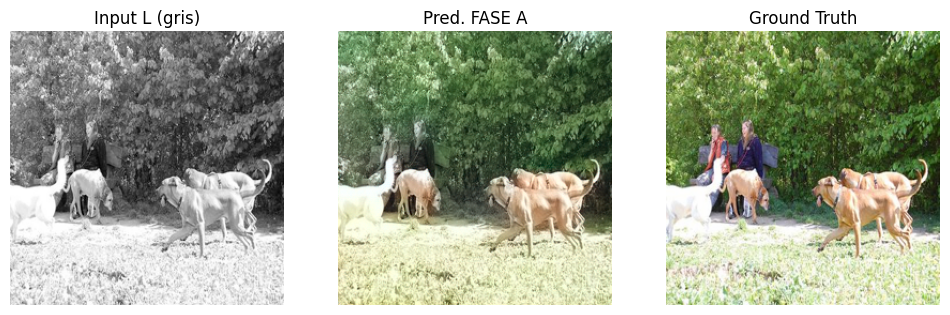

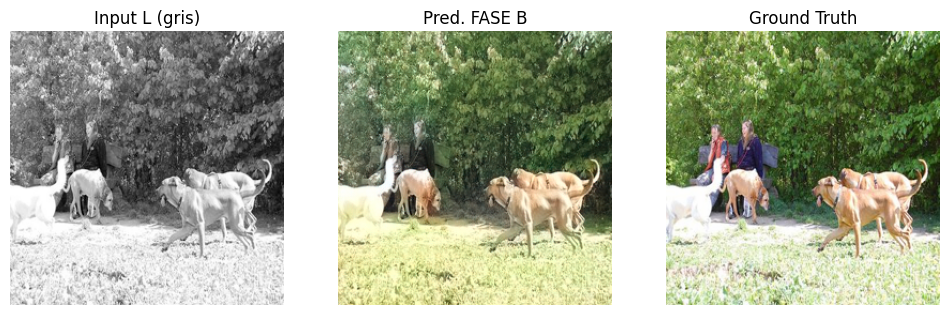

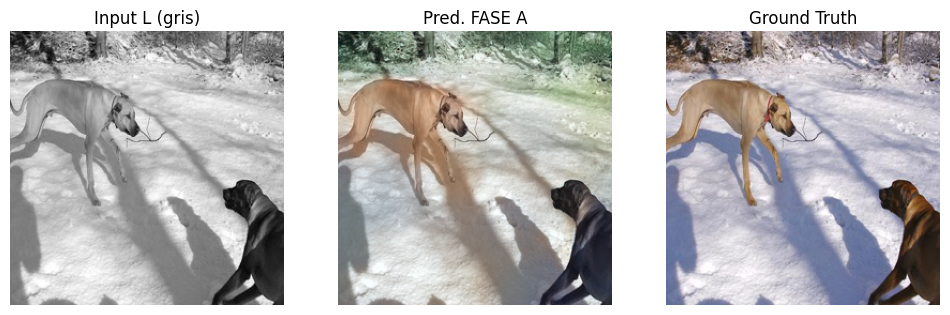

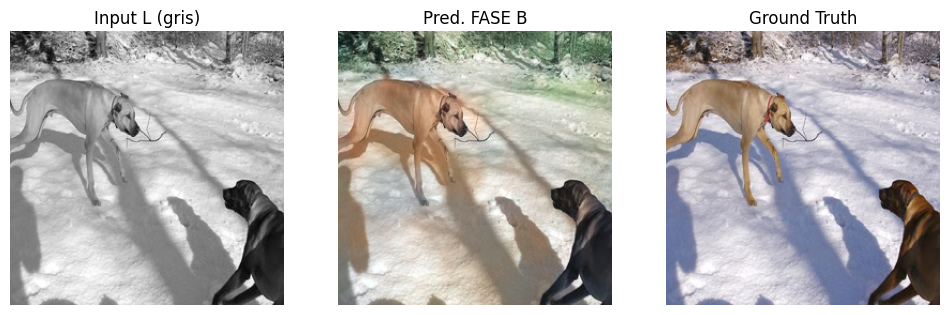

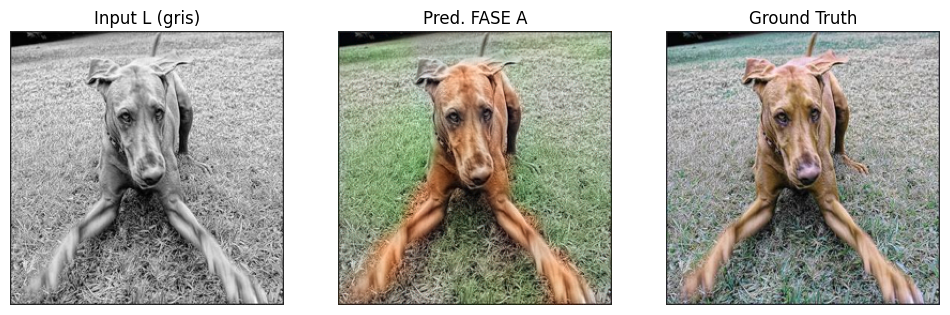

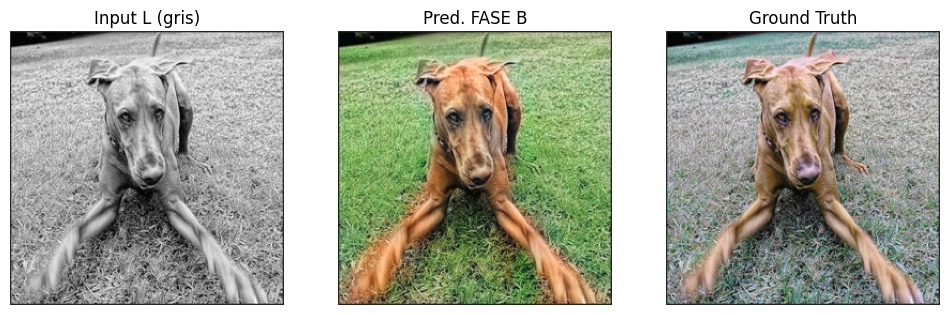

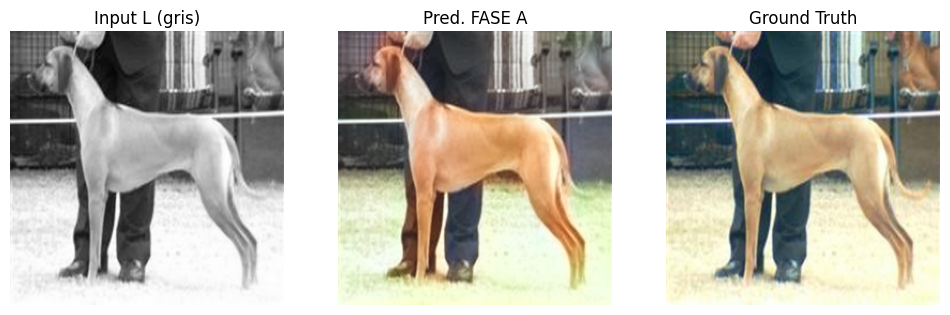

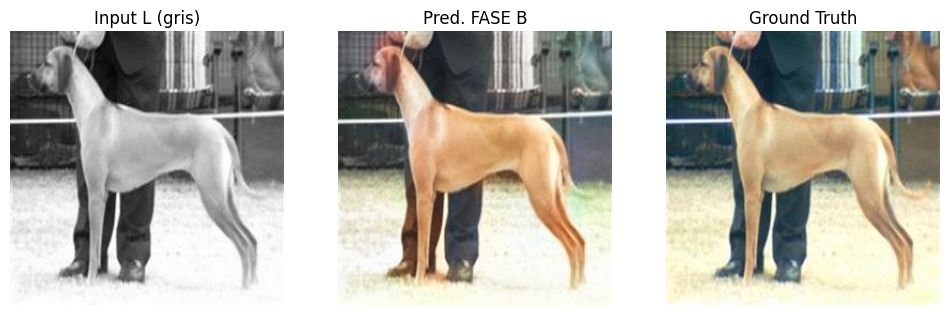

In [21]:
def visualizar_faseA_faseB(num_images=4):

    print("\n=== VISUALIZACIÓN FASE A y FASE B ===\n")

    genA = HybridVitUnetColorizer().to(device)
    genB = HybridVitUnetColorizer().to(device)

    checkpointA = torch.load("checkpoints/best_model_FASE_A.pth", map_location=device)
    checkpointB = torch.load("checkpoints/best_model_FASE_B.pth", map_location=device)

    genA.load_state_dict(checkpointA["generator_state_dict"])
    genB.load_state_dict(checkpointB["generator_state_dict"])

    genA.eval()
    genB.eval()

    L_batch, ab_batch = fixed_vis_batch
    L_batch = L_batch.to(device)
    ab_batch = ab_batch.to(device)

    with torch.no_grad():
        fakeA = genA(L_batch)
        fakeB = genB(L_batch)

    rgbA = lab_to_rgb(L_batch, fakeA).cpu()
    rgbB = lab_to_rgb(L_batch, fakeB).cpu()
    rgbGT = lab_to_rgb(L_batch, ab_batch).cpu()

    for i in range(num_images):
        fig, axs = plt.subplots(1, 3, figsize=(12,4))
        axs[0].imshow(L_batch[i,0].cpu(), cmap='gray')
        axs[0].set_title("Input L (gris)")

        axs[1].imshow(rgbA[i].permute(1,2,0))
        axs[1].set_title("Pred. FASE A")

        axs[2].imshow(rgbGT[i].permute(1,2,0))
        axs[2].set_title("Ground Truth")

        for ax in axs:
            ax.axis("off")

        plt.show()

        fig, axs = plt.subplots(1, 3, figsize=(12,4))
        axs[0].imshow(L_batch[i,0].cpu(), cmap='gray')
        axs[0].set_title("Input L (gris)")

        axs[1].imshow(rgbB[i].permute(1,2,0))
        axs[1].set_title("Pred. FASE B")

        axs[2].imshow(rgbGT[i].permute(1,2,0))
        axs[2].set_title("Ground Truth")

        for ax in axs:
            ax.axis("off")

        plt.show()

visualizar_faseA_faseB(4)
